### Jupyter notebook for practice quiz for lesson 2.3.3
This Jupyter notebook executes the "processDynamic.m" code to generate a dynamic cell model from cell-test data. The results computed by this notebook will be used to answer questions in the practice quiz for lesson 2.3.3.

In [10]:
% Set the toolkit to gnuplot
graphics_toolkit('gnuplot');

% langsung jalankan processDyanmic
clear all
temps = 25;

numpoles = 1; % number of resistor--capacitor pairs in final model
doHyst = 1;   % whether to include hysteresis in model

% Read model OCV file
modelFile = sprintf('staticModel-ocv.mat');
load(modelFile);

% used by fminbnd later on
options=optimset('TolX',1e-8,'TolFun',1e-8,'MaxFunEval',100000, ...
 'MaxIter',1e6,'Jacobian','Off'); % for later optimization
options=optimset('TolX',0.1,'TolFun',1e-2,'MaxFunEval',40, ...
 'MaxIter',20,'Jacobian','Off'); % for later optimization

% Persiapkan data, numpoles, dan doHyst
numpoles = 1; % 1 RC pair
doHyst = 1;   % do Hysteresis

% load "cell_18ah_dynStep1.csv" and dynStep2.csv
% and plot it
% 1. Load the data (skipping the first 6 lines of headers in your CSV)
raw_data1 = dlmread('cell_18ah_dynStep1.csv', ',', 7, 0);
raw_data2 = dlmread('cell_18ah_dynStep2.csv', ',', 15, 0);

% Force raw_data2 to only have the first 3 columns
raw_data2 = raw_data2(:, 1:3);
% Calculate the last timestamp of the first file
last_time = raw_data1(end, 1);

% Add that offset to the time column (column 1) of the second file
raw_data2(:, 1) = raw_data2(:, 1) + last_time;

% Now combine them
raw_data = [raw_data1; raw_data2];

% 2. Initialize an empty structure (This prevents the "empty structure array" error)
data = struct();

% 3. Assign the columns to the structure fields
% Column 1: Time(S), Column 2: Cur(A), Column 3: Vol(V)
data.script1.time = raw_data(:, 1);
data.script1.current = raw_data(:, 2);
data.script1.voltage = raw_data(:, 3);

%freeing data from memory
clear raw_data raw_data1 raw_data2;

In [6]:
% Now, script2 - vmin and dither_vmin
% load "cell_18ah_dynStep3_vmin.csv" and dynStep3_dither_vmin.csv
% and plot it
% 1. Load the data (skipping the first 6 lines of headers in your CSV)
raw_data1 = dlmread('cell_18ah_dynStep3_vmin.csv', ',', 8, 0);
raw_data2 = dlmread('cell_18ah_dynStep3_dither_vmin.csv', ',', 27, 0);

% Force raw_data2 to only have the first 3 columns
raw_data2 = raw_data2(:, 1:3);
% Calculate the last timestamp of the first file
last_time = raw_data1(end, 1);

% Add that offset to the time column (column 1) of the second file
raw_data2(:, 1) = raw_data2(:, 1) + last_time;

% Now combine them
raw_data = [raw_data1; raw_data2];

% 3. Assign the columns to the structure fields
% Column 1: Time(S), Column 2: Cur(A), Column 3: Vol(V)
data.script2.time = raw_data(:, 1);
data.script2.current = raw_data(:, 2);
data.script2.voltage = raw_data(:, 3);

%freeing data from memory
clear raw_data raw_data1 raw_data2;

% 4. Save to the MAT file
% save('cell_18ah_dynStep1.mat', 'data');

In [7]:
% Now, script3 - vmax and dither_vmax
% load "cell_18ah_dynStep4_vmax.csv" and dynStep4_dither_vmax.csv
% and plot it
% 1. Load the data (skipping the first 6 lines of headers in your CSV)
raw_data1 = dlmread('cell_18ah_dynStep4_vmax.csv', ',', 8, 0);
raw_data2 = dlmread('cell_18ah_dynStep4_dither_vmax.csv', ',', 27, 0);

% Force raw_data2 to only have the first 3 columns
raw_data2 = raw_data2(:, 1:3);
% Calculate the last timestamp of the first file
last_time = raw_data1(end, 1);

% Add that offset to the time column (column 1) of the second file
raw_data2(:, 1) = raw_data2(:, 1) + last_time;

% Now combine them
raw_data = [raw_data1; raw_data2];

% 3. Assign the columns to the structure fields
% Column 1: Time(S), Column 2: Cur(A), Column 3: Vol(V)
data.script3.time = raw_data(:, 1);
data.script3.current = raw_data(:, 2);
data.script3.voltage = raw_data(:, 3);

%freeing data from memory
clear raw_data raw_data1 raw_data2;

% 4. Save to the MAT file
save('cell_18ah_dynStep.mat', 'data');

### Visualizing data
There is an enormous amount of data stored from these four cell tests. One good way to visualize the data is via plotting. For example:

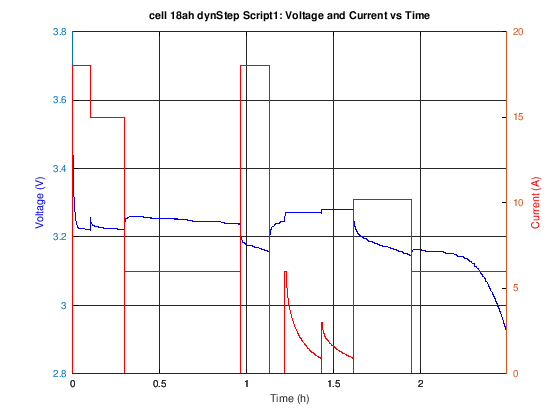

In [11]:
load cell_18ah_dynStep.mat;
[ax1, h1, h2] = plotyy(data.script1.time/3600, data.script1.voltage, data.script1.time/3600, data.script1.current);

% 5. Customize the line styles (Optional but makes it look better)
set(h1, 'linewidth', 2, 'color', 'b'); % Voltage line (Blue)
set(h2, 'linewidth', 2, 'color', 'r'); % Current line (Red)

% 6. Add labels and title
xlabel('Time (h)', 'fontsize', 12);
ylabel(ax1(1), 'Voltage (V)', 'fontsize', 12, 'color', 'b');
ylabel(ax1(2), 'Current (A)', 'fontsize', 12, 'color', 'r');
title('cell 18ah dynStep Script1: Voltage and Current vs Time', 'fontsize', 14);

grid on;

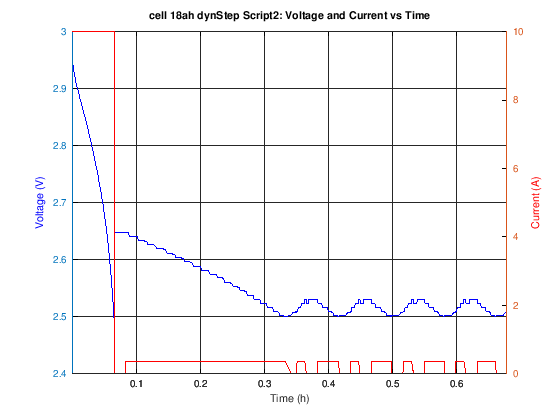

In [12]:
[ax2, h1, h2] = plotyy(data.script2.time/3600, data.script2.voltage, data.script2.time/3600, data.script2.current);

% 5. Customize the line styles (Optional but makes it look better)
set(h1, 'linewidth', 2, 'color', 'b'); % Voltage line (Blue)
set(h2, 'linewidth', 2, 'color', 'r'); % Current line (Red)

% 6. Add labels and title
xlabel('Time (h)', 'fontsize', 12);
ylabel(ax2(1), 'Voltage (V)', 'fontsize', 12, 'color', 'b');
ylabel(ax2(2), 'Current (A)', 'fontsize', 12, 'color', 'r');
title('cell 18ah dynStep Script2: Voltage and Current vs Time', 'fontsize', 14);
% 7. Add grid and legend

grid on;

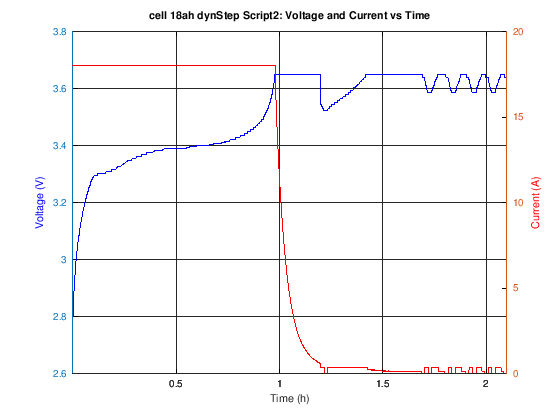

In [13]:
[ax3, h1, h2] = plotyy(data.script3.time/3600, data.script3.voltage, data.script3.time/3600, data.script3.current);

% 5. Customize the line styles (Optional but makes it look better)
set(h1, 'linewidth', 2, 'color', 'b'); % Voltage line (Blue)
set(h2, 'linewidth', 2, 'color', 'r'); % Current line (Red)

% 6. Add labels and title
xlabel('Time (h)', 'fontsize', 12);
ylabel(ax3(1), 'Voltage (V)', 'fontsize', 12, 'color', 'b');
ylabel(ax3(2), 'Current (A)', 'fontsize', 12, 'color', 'r');
title('cell 18ah dynStep Script2: Voltage and Current vs Time', 'fontsize', 14);
% 7. Add grid and legend

grid on;

In [14]:
% ------------------------------------------------------------------
% Step 1: Compute capacity and coulombic efficiency for every test
% ------------------------------------------------------------------

% get disAh from each csv file and directly put into disAh variable
% get chgAh from each csv file and directly put into chgAh variable

% 1. Open the file for reading
fid = fopen('cell_18ah_dynStep1.csv', 'r');

% Variables to store our extracted capacities
totDisAh = 0;
totChgAh = 0;

% 2. Loop through the file line by line
while ~feof(fid)
    % Read the current line
    line = fgetl(fid);
    
    % Check if we reached the main data (so we can stop reading)
    if strncmp(line, 'Time(S)', 7)
        break; 
    end
    
    % 3. Look for step 1-3
    if strncmp(line, '*1-1', 4)
        % Split the line into parts using the comma as a delimiter
        % Example line: *1-3,C-CV,20.87,69.97
        parts = strsplit(line, ',');
        
        % The capacity is the 3rd item. Convert it from text to a number
        totDisAh = totDisAh + str2double(parts{3});
    end
end

% 5. Close the file (important to free up system resources!)
fclose(fid);
% first initialize disAh
% 15.833 data from dynStep2.csv
data.script1.disAh = totDisAh + 16.663;
data.script1.chgAh = 0.78;

% script2.disAh dari Step3_vmin dan Step3_dither_vmin
data.script2.disAh = 0.646 + 0.134;
data.script2.chgAh = 0.02;

% script3.disAh dari step4_dither_vmax
data.script3.disAh = 0.03;
data.script3.chgAh = 0.161 + 18.57;
% sum all totDisAh
totDisAh = data.script1.disAh + data.script2.disAh + data.script3.disAh;
totChgAh = data.script1.chgAh + data.script2.chgAh + data.script3.chgAh;
eta25 = totDisAh/totChgAh;

data.script1.chgAh = data.script1.chgAh*eta25;
data.script2.chgAh = data.script2.chgAh*eta25;
data.script3.chgAh = data.script3.chgAh*eta25;    

Q25 = data.script1.disAh(end) + data.script2.disAh(end) -...
      data.script1.chgAh(end) - data.script2.chgAh(end);
data.Q = Q25;
% Display the results
fprintf('Capacity for Charge Ah: %.3f Ah\n', totChgAh);
fprintf('Capacity for Discharge Ah: %.3f Ah\n', data.script1.disAh);
fprintf('eta25: %.3f\n', eta25);
fprintf('Q25: %.3f\n', Q25);

model.temp = 25;
model.etaParam = NaN;
model.QParam = NaN;
































































Capacity for Charge Ah: 19.531 Ah

Capacity for Discharge Ah: 18.460 Ah

eta25: 0.987

Q25: 18.451






In [16]:
% ------------------------------------------------------------------
% Step 2: Compute OCV for "discharge portion" of test
% ------------------------------------------------------------------
% for k = 1:length(data),
    etaParam = model.etaParam;
    etaik = data.script1.current(:); % Forced to column vector
    etaik(etaik<0)= etaParam*etaik(etaik<0);
    % disp(etaik)
    data.Z = 1 - cumsum([0,etaik(1:end-1)])*1/(data.Q*3600); 
    data.OCV = OCVfromSOCtemp(data.Z(:),25,model);
% end










error: horizontal dimensions mismatch (1x1 vs 4464x1)

error: structure has no member 'Z'



In [ ]:
% ------------------------------------------------------------------
  % Step 3: Now, optimize!
  % ------------------------------------------------------------------
  numpoles = 1;
  model.GParam  = NaN; % "gamma" hysteresis parameter
  model.M0Param = NaN; % "M0" hysteresis parameter
  model.MParam  = NaN; % "M" hysteresis parameter
  model.R0Param = NaN; % "R0" ohmic resistance parameter
  model.RCParam = NaN(1,numpoles); % time const.
  model.RParam  = NaN(1,numpoles); % Rk

  fprintf('Processing temperature 25°C\n');
  bestcost = Inf;
  
  if doHyst,
    model.GParam = abs(fminbnd(@(x) optfn(x,data,model,25,doHyst),1,250,options));
  else
    model.GParam = 0;
    optfn(0,data,model,25,doHyst);
  end
  [~,model] = minfn(data,model,25,doHyst);                          


% --------------------------------------------------------------------
% This minfn works for the enhanced self-correcting cell model
% --------------------------------------------------------------------
function cost=optfn(theGParam,data,model,theTemp,doHyst)
  global bestcost 
  
  model.GParam = abs(theGParam);
  [cost,model] = minfn(data,model,theTemp,doHyst);
  if cost<bestcost, % update plot of model params for every improvement
    bestcost = cost;
    disp('  The model created for this value of gamma is the best ESC model yet!');
  end
return

% --------------------------------------------------------------------
% minfn helper (Simplified for single dataset)
% --------------------------------------------------------------------
function [cost,model]=minfn(data,model,theTemp,doHyst)
  G = abs(getParamESC('GParam',25,model));
  Q = abs(getParamESC('QParam',25,model));
  eta = abs(getParamESC('etaParam',25,model));
  RC = getParamESC('RCParam',25,model);
  numpoles = length(RC);
  
  ik = data.script1.current(:);
  vk = data.script1.voltage(:);
  tk = (1:length(vk))-1;
  etaik = ik; etaik(ik<0) = etaik(ik<0)*eta;

  h=0*ik; sik = 0*ik;
  fac=exp(-abs(G*etaik/(3600*Q)));
  for k=2:length(ik),
    h(k)=fac(k-1)*h(k-1)+(fac(k-1)-1)*sign(ik(k-1));
    sik(k) = sign(ik(k));
    if abs(ik(k))<Q/100, sik(k) = sik(k-1); end
  end
  
  % First modeling step
  vest1 = data.OCV;
  verr = vk - vest1;
  
  % Second modeling step
  np = numpoles; 
  while 1,
    A = SISOsubid(-diff(verr),diff(etaik),np);
    eigA = eig(A); 
    eigA = eigA(eigA == conj(eigA));  
    eigA = eigA(eigA > 0 & eigA < 1); 
    okpoles = length(eigA); np = np+1;
    if okpoles >= numpoles, break; end
    fprintf('Trying np = %d\n',np);
  end    
  RCfact = sort(eigA); RCfact = RCfact(end-numpoles+1:end);
  RC = -1./log(RCfact);
  
  vrcRaw = zeros(numpoles,length(h));
  for k=2:length(ik),
    vrcRaw(:,k) = diag(RCfact)*vrcRaw(:,k-1) + (1-RCfact)*etaik(k-1);
  end
  vrcRaw = vrcRaw';

  % Third modeling step
  if doHyst,
    H = [h,sik,-etaik,-vrcRaw]; 
    W = lsqnonneg(H,verr); 
    M = W(1); M0 = W(2); R0 = W(3); Rfact = W(4:end)';
  else
    H = [-etaik,-vrcRaw]; 
    W = H\verr;    
    M=0; M0=0; R0 = W(1); Rfact = W(2:end)';
  end
  
  model.R0Param = R0;
  model.M0Param = M0;
  model.MParam = M;
  model.RCParam = RC';
  model.RParam = Rfact';
  
  vest2 = vest1 + M*h + M0*sik - R0*etaik - vrcRaw*Rfact';
  verr = vk - vest2;
      
  % Compute RMS error roughly in 5% to 95% SOC
  v1 = OCVfromSOCtemp(0.95,25,model);
  v2 = OCVfromSOCtemp(0.05,25,model);
  N1 = find(vk<v1,1,'first'); N2 = find(vk<v2,1,'first');
  if isempty(N1), N1=1; end; if isempty(N2), N2=length(verr); end
  
  cost=sqrt(mean(verr(N1:N2).^2));    
  fprintf('  RMS error for present value of gamma = %0.2f (mV)\n',cost*1000);
  
  if isnan(cost), error('Cost evaluated to NaN. Stopping.'), end
return

% --------------------------------------------------------------------
% SISOsubid helper (Unchanged)
% --------------------------------------------------------------------
function A = SISOsubid(y,u,n)
  y = y(:); y = y'; ny = length(y); 
  u = u(:); u = u'; nu = length(u); 
  i = 2*n; 
  twoi = 4*n;           

  if ny ~= nu, error('y and u must be same size'); end
  if ((ny-twoi+1) < twoi); error('Not enough data points'); end

  j = ny-twoi+1;

  Y=zeros(twoi,j); U=zeros(twoi,j);
  for k=1:2*i
    Y(k,:)=y(k:k+j-1); U(k,:)=u(k:k+j-1);
  end
  R = triu(qr([U;Y]'))'; 
  R = R(1:4*i,1:4*i); 	 

  Rf = R(3*i+1:4*i,:);              
  Rp = [R(1:1*i,:);R(2*i+1:3*i,:)]; 
  Ru  = R(1*i+1:2*i,1:twoi); 	      
  Rfp = [Rf(:,1:twoi) - (Rf(:,1:twoi)/Ru)*Ru,Rf(:,twoi+1:4*i)]; 
  Rpp = [Rp(:,1:twoi) - (Rp(:,1:twoi)/Ru)*Ru,Rp(:,twoi+1:4*i)]; 

  if (norm(Rpp(:,3*i-2:3*i),'fro')) < 1e-10
    Ob = (Rfp*pinv(Rpp')')*Rp; 	
  else
    Ob = (Rfp/Rpp)*Rp;
  end

  WOW = [Ob(:,1:twoi) - (Ob(:,1:twoi)/Ru)*Ru,Ob(:,twoi+1:4*i)];
  [U,S,~] = svd(WOW);
  ss = diag(S);

  U1 = U(:,1:n); 

  gam  = U1*diag(sqrt(ss(1:n)));
  gamm = gam(1:(i-1),:);
  gam_inv  = pinv(gam); 			
  gamm_inv = pinv(gamm); 			

  Rhs = [gam_inv*R(3*i+1:4*i,1:3*i),zeros(n,1); R(i+1:twoi,1:3*i+1)];
  Lhs = [gamm_inv*R(3*i+1+1:4*i,1:3*i+1); R(3*i+1:3*i+1,1:3*i+1)];
  sol = Lhs/Rhs;    
  A = sol(1:n,1:n); 
return

In [ ]:
disp(modelFile)

fieldnames(model)

disp(model)



### Using the model
Once the model has been created, you can load it from the file in which it was saved, and can look at its basic structures.

In [ ]:
% Load model data file
load P14model.mat
temps = model.temps % display the temperatures processed to create the model
capacities = model.QParam % display measured total capacities at each temperature

In [ ]:
% Plot model fields: resistances
subplot(1,2,1); plot(model.temps,1000*model.R0Param)
xlabel('Temperature (degC)'); ylabel('Resistance (mOhms)'); title('Series resistance versus temperature')
subplot(1,2,2); plot(model.temps,1000*model.RParam)
xlabel('Temperature (degC)'); ylabel('Resistance (mOhms)'); title('R-C resistance versus temperature')

In [ ]:
model.GParam()


In [ ]:
model.MParam()
